In [1]:
import numpy 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from omegaconf import OmegaConf
import json
import os
__DIR__ = os.path.dirname("../")
import sys
sys.path.append(__DIR__)
from datasets import load_from_disk, concatenate_datasets
import numpy as np
from tqdm import tqdm
import torch.nn.functional as F
import plotly.graph_objects as go
import matplotlib.cm as cm
from copy import deepcopy


In [2]:
from diff_masking.utils.phi3 import create_masked_phi

In [3]:
import torch

# Set the CUDA device
torch.cuda.set_device(0)  # Replace 1 with the desired CUDA device index

In [4]:
model_name = "microsoft/Phi-3-mini-128k-instruct"
model = AutoModelForCausalLM.from_pretrained( 
            model_name,  
            device_map="cuda:0",  
            torch_dtype=torch.bfloat16,  
            trust_remote_code=True,  
            attn_implementation="flash_attention_2"
) 

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [5]:
model_config = model.config

In [6]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [7]:
checkpoint = "../outputs/main/2024-10-26_09-47-07/"

In [8]:
with open(checkpoint+"config.json", 'r') as file:
    config_dict = json.load(file)

In [9]:
config = OmegaConf.create(config_dict)

In [10]:
# model = create_masked_phi(model, config.specs.target_layers, config.specs.init_prob, config.specs.tau)

In [11]:
model = create_masked_phi(model, config.specs.target_layers, config.specs.init_prob, config.specs.tau, checkpoint+"model.pth")

/media/data/nicolas/project/mechanisms/KG_networks/notebooks/../diff_masking/utils/phi3.py:384: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mask_parameters = torch.load(ch

In [12]:
model.cuda()
torch.cuda.empty_cache()

In [13]:
for l in config.specs.target_layers:
    model.model.layers._modules[str(l)].self_attn.mask_enabled = True
    model.model.layers._modules[str(l)].mlp.mask_enabled = True

In [14]:
def get_mask(mask_param, tau, training, binary=True):
    if training:
        U1 = torch.rand_like(mask_param).requires_grad_(False)
        U1 += (U1<=1e-12)*1e-12
        U2 = torch.rand_like(mask_param).requires_grad_(False)
        U2 += (U2<=1e-12)*1e-12
        mask = F.sigmoid((mask_param-torch.log(torch.log(U1)/torch.log(U2))) / tau)
    else:
        mask = F.sigmoid(mask_param / tau)
    if binary:
        return (mask>0.5).int() 
    else:
        return mask

In [15]:
layer_weights = {}
for name, param in model.named_parameters():
    if "mask" in name:
        layer_weights[name] = param.detach()

In [16]:
del model
torch.cuda.empty_cache()

In [17]:
weights = layer_weights["model.layers.18.self_attn.mask_qkv_proj"]
weights.shape

torch.Size([9216, 3072])

In [18]:
num_heads = model_config.num_attention_heads
head_dim = model_config.hidden_size // num_heads 
num_key_value_heads = model_config.num_key_value_heads
hidden_size = model_config.hidden_size
hidden_size

3072

In [19]:
query_pos = num_heads * head_dim
query_pos

3072

In [20]:
op_size = num_heads * head_dim + 2 * (num_key_value_heads * head_dim)
op_size

9216

In [21]:
query_pos + num_key_value_heads * head_dim

6144

In [22]:
value_states = weights[query_pos + num_key_value_heads * head_dim :, ...]


In [23]:
value_states_pca = []
for k, v in tqdm(layer_weights.items()):
    if "mask_qkv_proj" in k:
        for i in range(25):
            mask = get_mask(v, 1.0, True, False)
            value_states = mask[query_pos + num_key_value_heads * head_dim :, ...]
            value_states_pca.append(value_states.cpu())
value_states_pca = torch.stack(value_states_pca).float().view(len(value_states_pca),-1)

100%|██████████| 60/60 [00:04<00:00, 14.38it/s]


In [24]:
del layer_weights

In [25]:
(U, S, V) = torch.pca_lowrank(value_states_pca, center=True)

In [26]:
pca_ = torch.matmul(value_states_pca, V[:, :3])

In [27]:
pca_.shape

torch.Size([375, 3])

In [28]:
import plotly.graph_objects as go

# Sample data: replace these with your actual data points
x = pca_[:, 0].cpu().numpy()
y = pca_[:, 1].cpu().numpy()
z = pca_[:, 2].cpu().numpy()
color_values = torch.arange(0, 15).repeat_interleave(pca_.shape[0]//15).cpu().numpy()

# Create 3D scatter plot with color mapping
fig = go.Figure(data=[go.Scatter3d(
    x=x,
    y=y,
    z=z,
    mode='markers',
    marker=dict(
        size=5,
        color=color_values,        # Set color based on color values
        colorscale='Viridis',      # Choose a colorscale, e.g., 'Viridis', 'Cividis', etc.
        colorbar=dict(title='Color')
    )
)])

# Update layout for better visualization
fig.update_layout(scene=dict(
    xaxis_title='X Axis',
    yaxis_title='Y Axis',
    zaxis_title='Z Axis'
))

fig.show()


In [113]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# Example: Generating a random sparse matrix for demonstration
np.random.seed(0)
value_states = weights[query_pos + num_key_value_heads * head_dim :, ...]
matrix = get_mask(value_states, 1.0, True, True).cpu().numpy()
# Extract coordinates of non-zero elements
non_zero_coords = np.column_stack(np.nonzero(matrix))

# Applying DBSCAN to the coordinates of non-zero elements
# You may need to tune eps (neighborhood radius) and min_samples (min points in a neighborhood)
dbscan = DBSCAN(eps=5, min_samples=20)
labels = dbscan.fit_predict(non_zero_coords)
len(np.unique(labels))

774

In [114]:
zero_coords = np.column_stack(np.nonzero(matrix<1.0))
zero_labels = np.full(zero_coords.shape[0], -1)
labels_concat = np.concatenate([labels, zero_labels])

In [115]:
coord = np.concatenate([non_zero_coords, zero_coords])
coord.shape

(9437184, 2)

In [116]:
t = torch.zeros(matrix.shape).long()
coord = torch.tensor(coord)
labels_concat = torch.tensor(labels_concat)

In [117]:
t[coord[:,0], coord[:,1]] = labels_concat

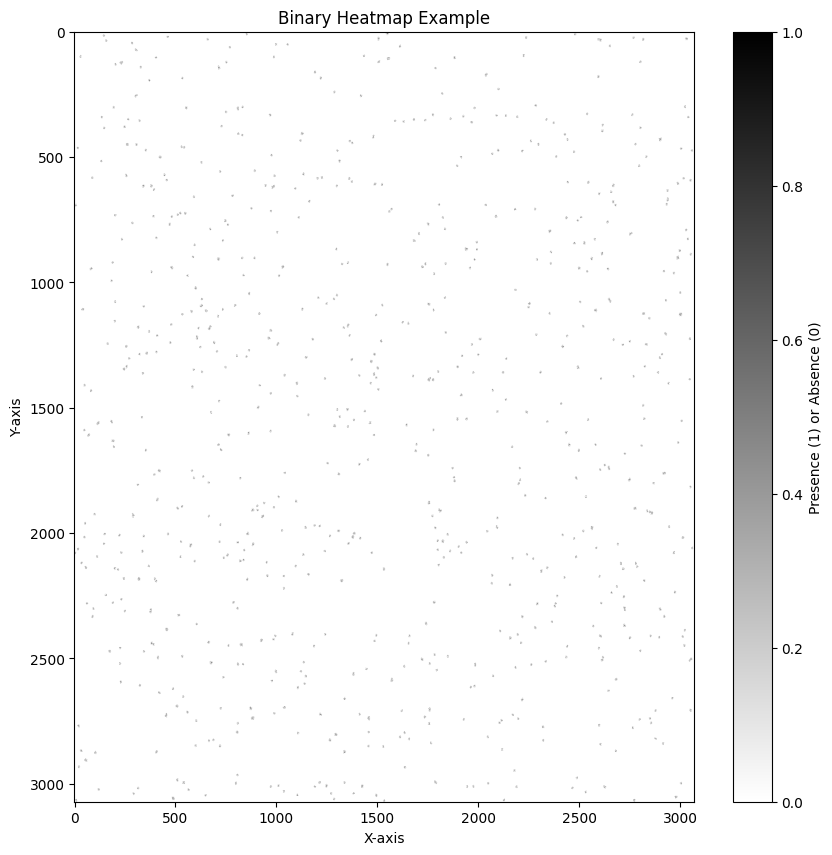

In [118]:

# Plotting the heatmap using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow((t.numpy()!=-1), aspect='auto', cmap="binary")  # Set colormap to 'binary' for black and white mapping
plt.colorbar(label='Presence (1) or Absence (0)')
plt.title('Binary Heatmap Example')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()


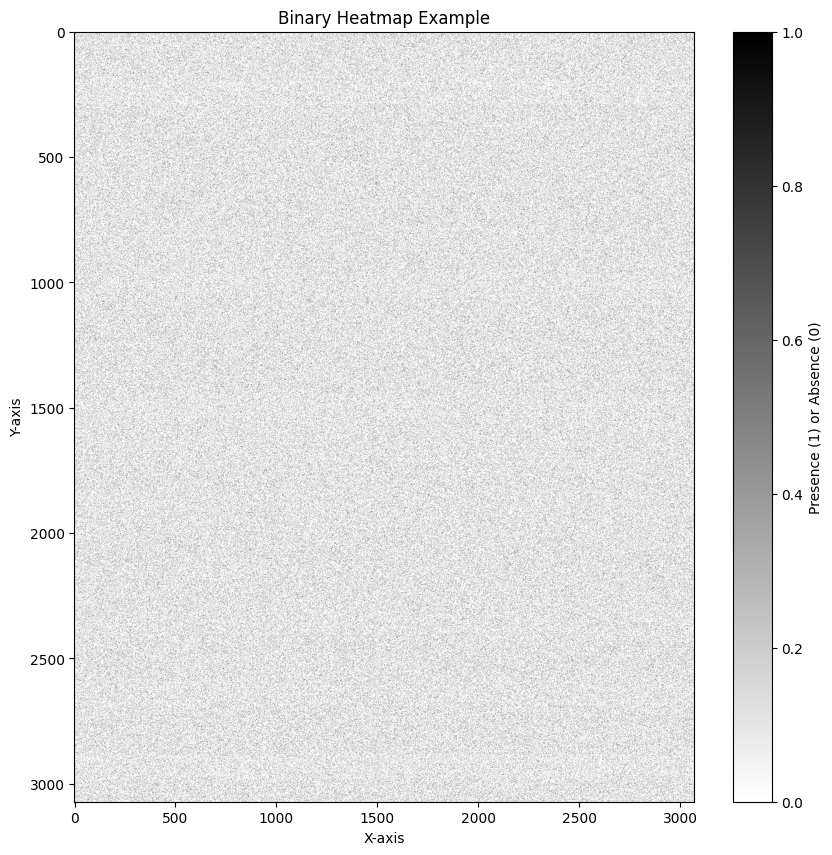

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Example data for the heatmap
value_states = weights[query_pos + num_key_value_heads * head_dim :, ...]
matrix = get_mask(value_states, 1.0, True, True).cpu().numpy()
# Plotting the heatmap using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(matrix, aspect='auto', cmap='binary')  # Set colormap to 'binary' for black and white mapping
plt.colorbar(label='Presence (1) or Absence (0)')
plt.title('Binary Heatmap Example')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()


In [45]:
stochastic = False
N = 25 if stochastic else 1

In [46]:
target_layers = np.array(list(config.specs.target_layers))

def plot_densities(densities):
    keys =  ["query_states", "value_states", "key_states", "mask_down_proj", "mask_gate_up_proj", "mask_o_proj"]
    colors = cm.viridis(np.linspace(0, 1, len(keys)))
    fig = go.Figure()

    for key, color in zip(keys, colors):
        if "states" in key:
            y = np.array([v[key][1].item() for k, v in densities.items() if "qkv_proj" in k])
            if stochastic:
                std = np.array([v[key][0].item() for k, v in densities.items() if "qkv_proj" in k])

                upper_bound = y + std
                lower_bound = y - std

        else:
            y = [v["mean"].item() for k, v in densities.items() if key in k]
        shaded_color = deepcopy(color)
        shaded_color[-1] = 0.2
        
        fig.add_trace(go.Scatter(x=target_layers, y=y, mode='lines', name=f"mean-{key}", line=dict(color=f'rgba{tuple(color)}')))
        if stochastic:
            fig.add_trace(go.Scatter(
                x=np.concatenate([target_layers, target_layers[::-1]]),
                y=np.concatenate([upper_bound, lower_bound[::-1]]),
                fill='toself',
                fillcolor=f'rgba{tuple(shaded_color)}',
                line=dict(color=f'rgba{tuple(shaded_color)}'),
                hoverinfo="skip",
                name=f"std-{key}"
            ))

    # Add title and labels
    fig.update_layout(
        title="Stochastic densities",
        xaxis_title="Target Layers",
        yaxis_title="Density",
        width=800,
        height=600
    )

    # Show the figure
    fig.show()


In [42]:
densities = {}

for k, v in tqdm(layer_weights.items()):
    if "mask_qkv_proj" in k:
        percent = {"query_states":[], "key_states":[], "value_states":[]}
        for i in range(N):
            mask = get_mask(v, 1.0, stochastic)
            query_states = mask[query_pos,...]
            key_states = mask[query_pos : query_pos + num_key_value_heads * head_dim, ...]
            value_states = mask[query_pos + num_key_value_heads * head_dim :, ...]
            percent["query_states"].append(query_states.sum()/query_states.numel())
            percent["key_states"].append(key_states.sum()/key_states.numel())
            percent["value_states"].append(value_states.sum()/value_states.numel())
        
        densities[k] = {}
        densities[k] = {key: torch.std_mean(torch.stack(p)) for key, p in percent.items()}

    else: 
        percent = []
        for i in range(N):
            mask = get_mask(v, 1.0, stochastic)
            percent.append(mask.sum()/mask.numel())

        densities[k] = {}
        densities[k]["mean"] = torch.stack(percent).mean()
        densities[k]["std"] = torch.stack(percent).std()      


  0%|          | 0/60 [00:00<?, ?it/s]/tmp/ipykernel_2323952/3026896296.py:26: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at ../aten/src/ATen/native/ReduceOps.cpp:1808.)
  densities[k]["std"] = torch.stack(percent).std()
/tmp/ipykernel_2323952/3026896296.py:16: UserWarning: std_mean(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at ../aten/src/ATen/native/ReduceOps.cpp:1808.)
  densities[k] = {key: torch.std_mean(torch.stack(p)) for key, p in percent.items()}
100%|██████████| 60/60 [00:00<00:00, 1059.81it/s]


In [70]:

plot_densities(densities)

In [73]:
plot_densities(densities)

In [25]:
plot_densities(densities)

In [47]:
plot_densities(densities)